In [1]:
import EFC_learningfMRI.globals as gl
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from EFC_learningfMRI.vis import plot_im_sess, custom_legend


base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


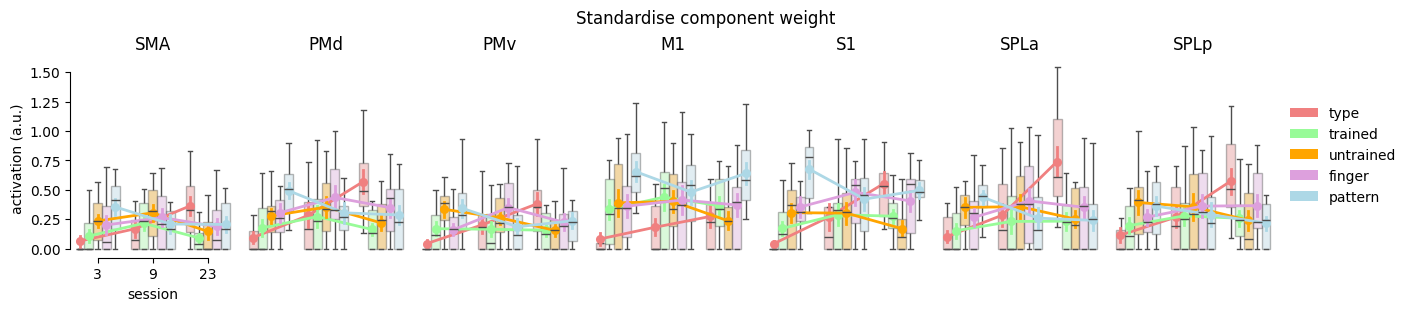

In [4]:
H = 'L'
atlas = 'ROI'
rois = gl.rois[atlas]
glm = 3
comp_names = ['type', 'trained', 'untrained', 'finger', 'pattern'] 
df = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'component_model.{atlas}.glm{glm}.tsv'), sep='\t')
N = df.sn.nunique()

# divide all components by the noise component within each subject/roi/session/hemisphere
keys = ['sn', 'roi', 'sess', 'Hem']
noise = df[df.component=='noise'][keys + ['weight']].rename(columns={'weight': 'noise'})
df = df.merge(noise, on=keys)
df['weight_norm'] = np.sqrt(df['weight'] / df['noise'])
df = df.drop(columns='noise')

df = df[(df.component!='noise') & (df.Hem==H)]

hue_order = ['type', 'trained', 'untrained', 'finger', 'pattern']
colors = ['lightcoral', 'palegreen', 'orange', 'plum', 'lightblue']

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(14, 3), constrained_layout=True)
plot_im_sess(fig, axs, df, rois, y='weight_norm', x='sess', hue='component', hue_order=hue_order, palette=colors, kind='box', showfliers=False, boxprops=dict(alpha=.4))
plot_im_sess(fig, axs, df, rois, y='weight_norm', x='sess', hue='component', hue_order=hue_order, palette=colors, kind='point', dodge=.65)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('activation (a.u.)')
axs[-1].get_legend().remove()
custom_legend(fig, labels=hue_order, colors=colors, kind='box')
axs[0].set_xlabel('session')
fig.suptitle(f'Standardise component weight')

plt.show()

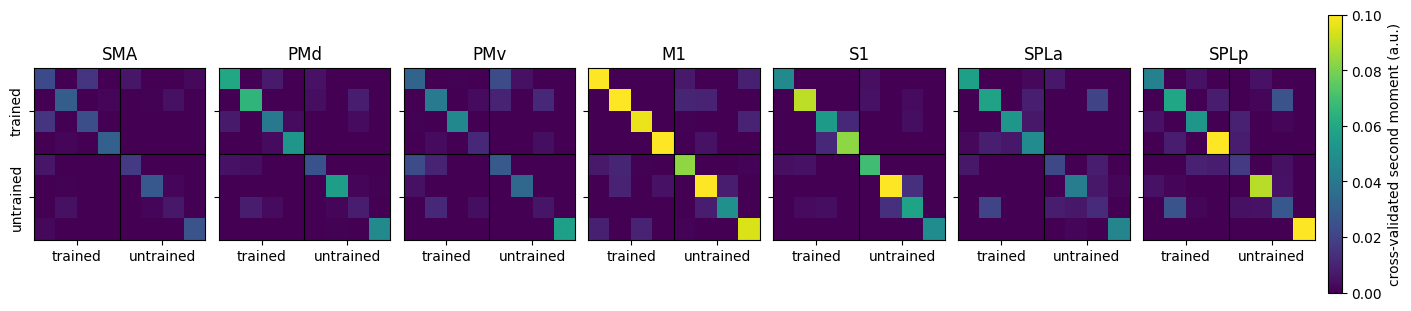

In [3]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(14, 3), constrained_layout=True)

sess = 1

vmin, vmax = 0, .1

for r, roi in enumerate(rois):
    ax = axs[r]
    
    G = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'G_obs.chord-session.glm{glm}.{H}.{roi}.npy'))

    im = ax.imshow(np.median(G[:, sess-1], axis=0), vmin=vmin, vmax=vmax)
    ax.set_title(roi)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([1.5, 5.5])
    ax.set_xticklabels(['trained', 'untrained'])
    ax.set_yticks([1.5, 5.5])
    ax.set_yticklabels(['trained', 'untrained'], rotation=90, va='center')

cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.01)
cbar.set_label('cross-validated second moment (a.u.)')

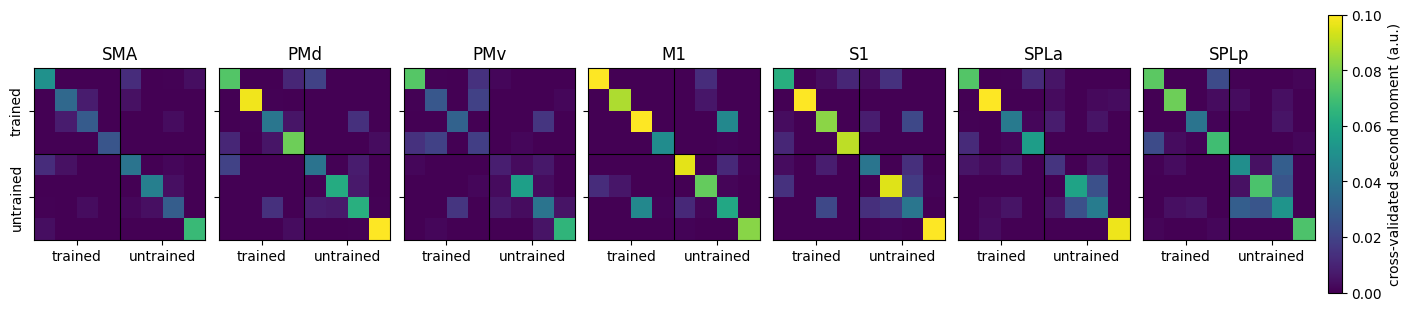

In [4]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(14, 3), constrained_layout=True)

sess = 2

vmin, vmax = 0, .1

for r, roi in enumerate(rois):
    ax = axs[r]
    
    G = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'G_obs.chord-session.glm{glm}.{H}.{roi}.npy'))

    im = ax.imshow(np.median(G[:, sess-1], axis=0), vmin=vmin, vmax=vmax)
    ax.set_title(roi)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([1.5, 5.5])
    ax.set_xticklabels(['trained', 'untrained'])
    ax.set_yticks([1.5, 5.5])
    ax.set_yticklabels(['trained', 'untrained'], rotation=90, va='center')

cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.01)
cbar.set_label('cross-validated second moment (a.u.)')

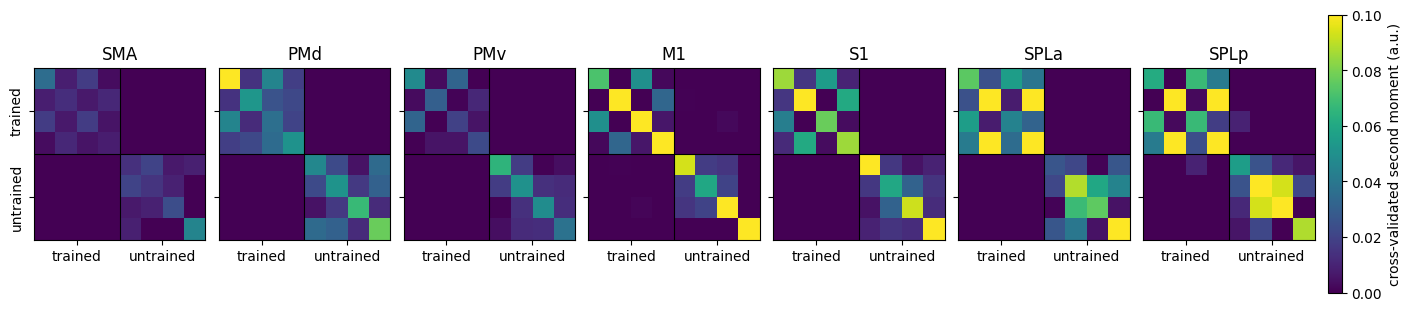

In [ ]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(14, 3), constrained_layout=True)

sess = 3

vmin, vmax = 0, .1

for r, roi in enumerate(rois):
    ax = axs[r]
    
    G = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'G_obs.chord-session.glm{glm}.{H}.{roi}.npy'))

    im = ax.imshow(np.median(G[:, sess-1], axis=0), vmin=vmin, vmax=vmax)
    ax.set_title(roi)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([1.5, 5.5])
    ax.set_xticklabels(['trained', 'untrained'])
    ax.set_yticks([1.5, 5.5])
    ax.set_yticklabels(['trained', 'untrained'], rotation=90, va='center')

cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.01)
cbar.set_label('cross-validated second moment (a.u.)')